## Dynamics of Cosmic Plasmas – Homework

In [1]:
# Preamble

%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

from IPython.display import HTML

import time, sys, warnings

import matplotlib as mpl
import numpy as np
import sympy as sym

from sympy import init_printing
init_printing(use_latex=True)

from sympy.utilities.lambdify import lambdify

import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter

from matplotlib.colors import ListedColormap
from matplotlib.legend_handler import HandlerTuple

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

N = 2**8

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(107/256, 1, N)
vals[:, 1] = np.linspace(142/256, 1, N)
vals[:, 2] = np.linspace(35/256, 1, N)

OliveDrab = ListedColormap(vals)
OliveDrab_r = OliveDrab.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(70/256, 1, N)
vals[:, 1] = np.linspace(130/256, 1, N)
vals[:, 2] = np.linspace(180/256, 1, N)

SteelBlue = ListedColormap(vals)
SteelBlue_r = SteelBlue.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(178/256, 1, N)
vals[:, 1] = np.linspace(34/256, 1, N)
vals[:, 2] = np.linspace(34/256, 1, N)

FireBrick = ListedColormap(vals)
FireBrick_r = FireBrick.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(218/256, 1, N)
vals[:, 1] = np.linspace(165/256, 1, N)
vals[:, 2] = np.linspace(32/256, 1, N)

GoldenRod = ListedColormap(vals)
GoldenRod_r = GoldenRod.reversed()

### 1) Electron Plasma Regimes

- Debye Length:

$$\lambda_D = \sqrt{\frac{\varepsilon_0 k_B T_e}{q_e^2 n_e}} \propto T_e^{1/2} n_e^{-1/2}$$

- Debye Number:

$$N_D = \tfrac{4}{3} \pi \lambda_D^3 n_e = \sqrt{\frac{16 \pi^2 \varepsilon_0^3 k_B^3 T_e^3}{9 q_e^6 n_e}} \propto T_e^{3/2} n_e^{-1/2}$$

- Fermi Temperature:

$$ \Theta_F = \frac{T_F}{T_e} = \frac{E_F}{k_B T_e} = \frac{\hbar^2}{2k_B m_e T_e} \sqrt[\scriptstyle 3 \,]{9\pi^4 n_e^2} \propto T_e^{-1} n_e^{2/3}$$

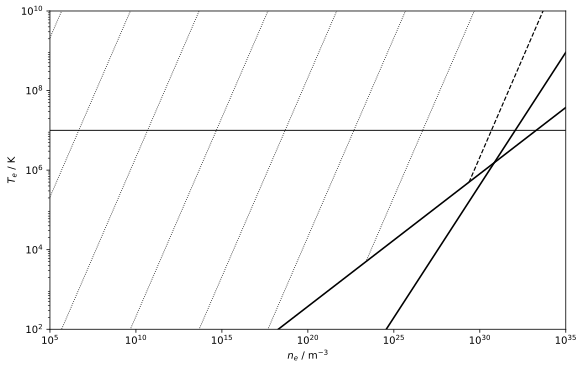

In [2]:
# Implementation

qe = 1.60217663e-19
me = 9.1093837e-31
kB = 1.38064852e-23
hbar = 1.05457182e-34
eps0 = 8.8541878188e-12

def Te_isoradius(ne, lD):
    return lD**2 * qe**2 * ne / (eps0 * kB)

def Te_isocoupling(ne, nD):
    return (nD**2 * 9 * qe**6 * ne / (16 * np.pi**2 * eps0**3 * kB**3))**(1/3)

def Te_isodegeneracy(ne, thF):
    return hbar**2 * (3 * np.pi**2 * ne)**(2/3) / (2 * kB * me * thF)

n = np.logspace(5, 35, 1000)

plt.plot(n, Te_isoradius(n, 1e-10), 'k--', lw=1.2, zorder=1)
plt.plot(n, Te_isoradius(n, 1e-8), 'k:', lw=0.8, zorder=1)
plt.plot(n, Te_isoradius(n, 1e-6), 'k:', lw=0.8, zorder=1)
plt.plot(n, Te_isoradius(n, 1e-4), 'k:', lw=0.8, zorder=1)
plt.plot(n, Te_isoradius(n, 1e-2), 'k:', lw=0.8, zorder=1)
plt.plot(n, Te_isoradius(n, 1e0), 'k:', lw=0.8, zorder=1)
plt.plot(n, Te_isoradius(n, 1e2), 'k:', lw=0.8, zorder=1)
plt.plot(n, Te_isoradius(n, 1e4), 'k:', lw=0.8, zorder=1)
plt.plot(n, Te_isocoupling(n, 1), 'k-', lw=1.6, zorder=3)
plt.plot(n, Te_isodegeneracy(n, 1), 'k-', lw=1.6, zorder=3)

plt.fill_between(n, Te_isocoupling(n, 1), color='w', zorder=2)

plt.plot([1e4, 1e36], [1e7, 1e7], 'k-', lw=0.9)

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e5, 1e35)
plt.ylim(1e2, 1e10)

plt.xticks(np.logspace(5, 35, 7))
plt.yticks(np.logspace(2, 10, 5))

plt.xlabel(r'$n_e$ / m$^{-3}$')
plt.ylabel(r'$T_e$ / K')

plt.show()
plt.close()

### 2) Saha Ionization Parameter